
Testing LLM Connection...

Agentic AI refers to artificial intelligence systems designed to act autonomously, making decisions and performing tasks without human intervention.


/var/folders/1h/8kw0jbt134d6sgxbnf23qrhr0000gn/T/ipykernel_61429/544511868.py:198: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send
/Users/utsabchakraborty/Documents/Edureka_May2026/Backup_LG/venv/lib/python3.14/site-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


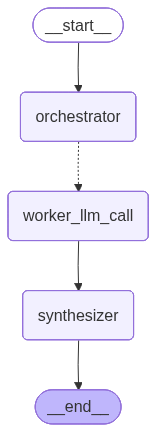



RUNNING ORCHESTRATOR-WORKER WORKFLOW

--- ORCHESTRATOR RUNNING ---
Topic: Agentic AI Applications in Retail

Generated Sections:

- Executive Summary: Provide a high-level overview of the report, summarizing the key findings and recommendations regarding the use of agentic AI applications in the retail sector.
- Introduction: Introduce the concept of agentic AI and its relevance to the retail industry. Define key terms and outline the scope and objectives of the report.
- Current State of AI in Retail: Discuss the current landscape of AI applications in the retail sector, highlighting existing technologies and their uses. Include statistics and examples of AI adoption in retail.
- Understanding Agentic AI: Explain what agentic AI is, how it differs from other forms of AI, and its potential capabilities. Discuss the theoretical underpinnings and technological advancements that enable agentic AI.
- Applications of Agentic AI in Retail: Explore various applications of agentic AI in the 

In [1]:
"""
====================================================================
LANGGRAPH ORCHESTRATOR-WORKER ARCHITECTURE
====================================================================

CONCEPTS TAUGHT:
----------------
1. Orchestrator-Worker Architecture
2. Dynamic Task Decomposition
3. Parallel Worker Execution
4. Send API in LangGraph
5. Dynamic Worker Creation
6. Shared Graph State
7. Reducers
8. Structured Outputs
9. Supervisor Agent Pattern
10. Parallelization vs Orchestration
11. Worker State Isolation
12. Result Aggregation
13. Report Synthesis
14. Enterprise AI Workflow Design
15. Observability & Streaming

ARCHITECTURE TYPE:
------------------
Supervisor-Orchestrated Dynamic Worker System

KEY IDEA:
---------
A central orchestrator:
1. Breaks a complex task into subtasks
2. Dynamically creates workers
3. Delegates work in parallel
4. Aggregates results
5. Synthesizes final output

WHY THIS PATTERN MATTERS:
-------------------------
Traditional workflows require:
- fixed tasks
- fixed nodes
- predictable execution

Orchestrator-worker workflows allow:
- dynamic decomposition
- adaptive planning
- scalable parallel execution

This is VERY useful for:
- report generation
- coding agents
- research systems
- multi-file code modification
- planning systems
- enterprise AI pipelines

IMPORTANT DISTINCTION:
----------------------
Parallelization:
- Tasks are predefined

Orchestrator-Worker:
- Tasks are dynamically generated
- Workers are dynamically created

"""

# ==============================================================
# STEP 1 — IMPORTS
# ==============================================================

import os
import operator

from typing import List
from typing import Annotated

from typing_extensions import TypedDict

from dotenv import load_dotenv

# ==============================================================
# STEP 2 — LOAD ENV VARIABLES
# ==============================================================

load_dotenv()

if not os.getenv("OPENAI_API_KEY"):

    raise ValueError(
        "OPENAI_API_KEY missing in .env file"
    )

os.environ["OPENAI_API_KEY"] = os.getenv(
    "OPENAI_API_KEY"
)

# Optional LangSmith tracing
os.environ["LANGCHAIN_PROJECT"] = os.getenv(
    "LANGCHAIN_PROJECT",
    "LangGraph-Orchestrator-Worker"
)

os.environ["LANGCHAIN_TRACING_V2"] = os.getenv(
    "LANGCHAIN_TRACING_V2",
    "true"
)

os.environ["LANGCHAIN_API_KEY"] = os.getenv(
    "LANGCHAIN_API_KEY",
    ""
)

# ==============================================================
# STEP 3 — CREATE LLM
# ==============================================================

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o",
    temperature=0
)

# ==============================================================
# STEP 4 — BASIC LLM TEST
# ==============================================================
# Always validate your LLM connection first.

print("\nTesting LLM Connection...\n")

test_result = llm.invoke(
    "What is Agentic AI in 20 words?"
)

print(test_result.content)

# ==============================================================
# STEP 5 — STRUCTURED OUTPUTS
# ==============================================================
# IMPORTANT CONCEPT:
#
# Structured outputs create reliable LLM outputs.
#
# MUCH better than:
# - string parsing
# - regex parsing
# - json.loads(response.content)

from pydantic import BaseModel, Field

# ==============================================================
# SECTION OBJECT
# ==============================================================
# Represents ONE section of a report.

class Section(BaseModel):

    name: str = Field(
        description="Name of the report section"
    )

    description: str = Field(
        description="Overview of the section"
    )

# ==============================================================
# MULTI-SECTION OBJECT
# ==============================================================
# Represents FULL report plan.

class Sections(BaseModel):

    sections: List[Section] = Field(
        description="List of report sections"
    )

# ==============================================================
# STEP 6 — STRUCTURED PLANNER LLM
# ==============================================================
# with_structured_output() forces
# reliable structured responses.

planner = llm.with_structured_output(
    Sections
)

# ==============================================================
# STEP 7 — SEND API
# ==============================================================
# VERY IMPORTANT LANGGRAPH CONCEPT
#
# Send() dynamically creates worker nodes.
#
# This is one of the most powerful features
# in LangGraph.

from langgraph.constants import Send

# ==============================================================
# STEP 8 — GRAPH STATE
# ==============================================================
# Shared state accessible to ALL nodes.

class State(TypedDict):

    # Main report topic
    topic: str

    # Planned report sections
    sections: List[Section]

    # Shared reducer state
    #
    # operator.add merges worker outputs
    # together automatically.
    completed_sections: Annotated[
        list,
        operator.add
    ]

    # Final synthesized report
    final_report: str

# ==============================================================
# STEP 9 — WORKER STATE
# ==============================================================
# IMPORTANT CONCEPT:
#
# Each worker has its OWN isolated state.
#
# Workers do NOT directly share state.
#
# Workers only contribute outputs
# to shared reducer keys.

class WorkerState(TypedDict):

    # Single section assigned to worker
    section: Section

    # Shared reducer output
    completed_sections: Annotated[
        list,
        operator.add
    ]

# ==============================================================
# STEP 10 — ORCHESTRATOR NODE
# ==============================================================
# The orchestrator:
# - plans work
# - decomposes tasks
# - creates subtasks
#
# IMPORTANT:
# This is SUPERVISOR architecture.

def orchestrator(state: State):

    """
    Create report plan dynamically.
    """

    print("\n--- ORCHESTRATOR RUNNING ---")

    topic = state["topic"]

    print(f"Topic: {topic}")

    # ==========================================================
    # Dynamic Task Decomposition
    # ==========================================================
    # LLM decides:
    # - how many sections
    # - which sections
    # - what subtasks are needed

    report_sections = planner.invoke(

        [
            {
                "role": "system",
                "content":
                """
                Generate a detailed report plan.

                Create:
                - logical report sections
                - clear structure
                - comprehensive coverage
                """
            },

            {
                "role": "user",
                "content":
                f"Generate report plan for: {topic}"
            }
        ]
    )

    print("\nGenerated Sections:\n")

    for sec in report_sections.sections:

        print(
            f"- {sec.name}: "
            f"{sec.description}"
        )

    # ==========================================================
    # Return Planned Sections
    # ==========================================================

    return {

        "sections": report_sections.sections
    }

# ==============================================================
# STEP 11 — WORKER NODE
# ==============================================================
# Worker agents execute subtasks.
#
# IMPORTANT CONCEPT:
# Workers operate independently in parallel.

def worker_llm_call(state: WorkerState):

    """
    Worker generates ONE section of report.
    """

    section = state["section"]

    print(
        f"\n--- WORKER RUNNING: "
        f"{section.name} ---"
    )

    # ==========================================================
    # Worker LLM Execution
    # ==========================================================

    response = llm.invoke(

        [
            {
                "role": "system",
                "content":
                """
                Write a detailed report section.

                REQUIREMENTS:
                - Use markdown
                - No introduction
                - No conclusion
                - Focus only on assigned section
                """
            },

            {
                "role": "user",
                "content":
                f"""
                Section Name:
                {section.name}

                Section Description:
                {section.description}
                """
            }
        ]
    )

    # ==========================================================
    # Workers write to shared reducer key
    # ==========================================================
    # operator.add automatically aggregates outputs.

    return {

        "completed_sections": [

            f"# {section.name}\n\n"
            f"{response.content}"
        ]
    }

# ==============================================================
# STEP 12 — DYNAMIC WORKER CREATION
# ==============================================================
# MOST IMPORTANT CONCEPT IN THIS EXAMPLE
#
# assign_workers():
# - dynamically creates workers
# - creates parallel execution
# - uses Send API
#
# This is what makes orchestrator-worker
# workflows special.

def assign_workers(state: State):

    """
    Dynamically create workers.
    """

    print("\n--- ASSIGNING WORKERS ---")

    sections = state["sections"]

    print(
        f"Creating {len(sections)} workers"
    )

    # ==========================================================
    # Send API
    # ==========================================================
    # Creates worker execution dynamically.
    #
    # Each worker gets:
    # - isolated worker state
    # - assigned section
    #
    # Workers run in parallel.

    return [

        Send(

            "worker_llm_call",

            {
                "section": section
            }

        )

        for section in sections
    ]

# ==============================================================
# STEP 13 — SYNTHESIZER NODE
# ==============================================================
# Aggregates worker outputs into final report.

def synthesizer(state: State):

    """
    Combine worker outputs into final report.
    """

    print("\n--- SYNTHESIZER RUNNING ---")

    completed_sections = state[
        "completed_sections"
    ]

    print(
        f"Received {len(completed_sections)} "
        f"completed sections"
    )

    # ==========================================================
    # Aggregate Results
    # ==========================================================

    final_report = "\n\n---\n\n".join(
        completed_sections
    )

    return {

        "final_report": final_report
    }

# ==============================================================
# STEP 14 — BUILD LANGGRAPH WORKFLOW
# ==============================================================

from langgraph.graph import (
    StateGraph,
    START,
    END
)

workflow = StateGraph(State)

# ==============================================================
# STEP 15 — ADD NODES
# ==============================================================

workflow.add_node(
    "orchestrator",
    orchestrator
)

workflow.add_node(
    "worker_llm_call",
    worker_llm_call
)

workflow.add_node(
    "synthesizer",
    synthesizer
)

# ==============================================================
# STEP 16 — ADD EDGES
# ==============================================================

workflow.add_edge(
    START,
    "orchestrator"
)

# ==============================================================
# DYNAMIC PARALLEL WORKER CREATION
# ==============================================================
# VERY IMPORTANT CONCEPT
#
# Orchestrator dynamically creates workers.

workflow.add_conditional_edges(

    "orchestrator",

    assign_workers,

    ["worker_llm_call"]
)

# ==============================================================
# Worker outputs go to synthesizer
# ==============================================================

workflow.add_edge(
    "worker_llm_call",
    "synthesizer"
)

workflow.add_edge(
    "synthesizer",
    END
)

# ==============================================================
# STEP 17 — COMPILE GRAPH
# ==============================================================
# Converts workflow definition
# into executable application.

orchestrator_worker_app = workflow.compile()

# ==============================================================
# STEP 18 — VISUALIZE GRAPH
# ==============================================================

from IPython.display import Image, display

try:

    display(

        Image(

            orchestrator_worker_app
            .get_graph()
            .draw_mermaid_png()

        )
    )

except Exception as e:

    print(
        "Visualization Error:",
        e
    )

# ==============================================================
# STEP 19 — EXECUTE WORKFLOW
# ==============================================================

print("\n")
print("=" * 70)
print("RUNNING ORCHESTRATOR-WORKER WORKFLOW")
print("=" * 70)

initial_state = {

    "topic":
    "Agentic AI Applications in Retail",

    "sections": [],

    "completed_sections": [],

    "final_report": ""
}

final_state = orchestrator_worker_app.invoke(
    initial_state
)

# ==============================================================
# STEP 20 — PRINT FINAL REPORT
# ==============================================================

print("\n")
print("=" * 70)
print("FINAL REPORT")
print("=" * 70)

print(
    final_state["final_report"]
)

# ==============================================================
# STEP 21 — STREAM EXECUTION
# ==============================================================
# VERY IMPORTANT CONCEPT:
#
# stream() enables observability.
#
# Critical for debugging agent systems.

print("\n")
print("=" * 70)
print("STREAMING EXECUTION")
print("=" * 70)

for event in orchestrator_worker_app.stream(
    initial_state
):

    print(event)

# ==============================================================
# STEP 22 — IMPORTANT TEACHING SUMMARY
# ==============================================================
#
# WHAT THIS EXAMPLE TAUGHT:
#
# 1. Dynamic Task Decomposition
# 2. Parallel Worker Execution
# 3. Supervisor Architectures
# 4. Shared Reducer State
# 5. Send API
# 6. Dynamic Worker Creation
# 7. Enterprise AI Orchestration
# 8. Result Aggregation
# 9. Structured Outputs
# 10. Observability
#
# MOST IMPORTANT TAKEAWAY:
#
# Orchestrator-worker workflows allow
# adaptive parallel execution where
# subtasks are determined dynamically.
#
# This is MUCH more flexible than
# fixed parallel workflows.
#
# REAL-WORLD USE CASES:
#
# - Coding Agents
# - Research Systems
# - Multi-file Refactoring
# - Enterprise Report Generation
# - Autonomous Planning Systems
# - Document Processing Pipelines
#

In [ ]:
from IPython.display import Markdown
Markdown(state["final_report"])